# Stock-Index Monte Carlo — Methodology Walkthrough

This notebook is the educational companion to `readme.txt`. It walks through the four pieces of the Monte Carlo methodology in order:

1. **Calibration** — estimate annual drift $\mu$ and volatility $\sigma$ from historical index returns.
2. **Simulation** — evolve many paths under geometric Brownian motion.
3. **Outputs** — percentile bands (the probability cone) and the probability of attaining a target.
4. **Convergence** — show the probability estimate stabilizing as the iteration count rises.

> This is a transparent demonstration of methodology, **not** a market forecast and **not** financial advice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from indices_mc.calibration import calibrate
from indices_mc.parameters import Parameters, DriftSpec
from indices_mc.engine import simulate
from indices_mc.analysis import percentile_bands, target_probability, convergence_curve
from indices_mc.plotting import plot_cone, plot_convergence

TICKER = "^GSPC"      # S&P 500 index
LOOKBACK_YEARS = 10
HORIZON_YEARS = 10
ITERATIONS = 20_000
SEED = 12345

## 1. Calibration

$\mu$ and $\sigma$ are estimated from realized daily log-returns over the lookback window, then annualized ($\mu_{\text{annual}} = \bar r \cdot 252$, $\sigma_{\text{annual}} = s_r \sqrt{252}$). The lookback choice is itself an assumption — it is reported on every run.

In [2]:
cal = calibrate(TICKER, lookback_years=LOOKBACK_YEARS)
print(cal.summary())

^GSPC: mu=0.1308/yr, sigma=0.1812/yr, spot=7,370.44 (calibrated on 2512 daily returns, 2016-06-27..2026-06-25, ~10.0y lookback)


## 2. Simulation

Each path evolves under GBM:

$$S(t+\Delta t) = S(t)\,\exp\!\Big((\mu - \tfrac{1}{2}\sigma^2)\,\Delta t + \sigma\sqrt{\Delta t}\,Z\Big), \quad Z \sim N(0,1)$$

The full ensemble is generated with vectorized NumPy. A fixed seed makes the run reproducible.

In [3]:
params = Parameters.from_calibration(
    cal,
    horizon_years=HORIZON_YEARS,
    n_iterations=ITERATIONS,
    seed=SEED,
)
result = simulate(params)
print(f"Simulated {result.paths.shape[0]:,} paths x {result.paths.shape[1]:,} steps")
print(f"Terminal mean = {result.terminal.mean():,.0f}  (GBM theory: {params.spot*np.exp(cal.mu*HORIZON_YEARS):,.0f})")

Simulated 20,000 paths x 2,521 steps
Terminal mean = 27,035  (GBM theory: 27,267)


## 3. Outputs — the probability cone and a target probability

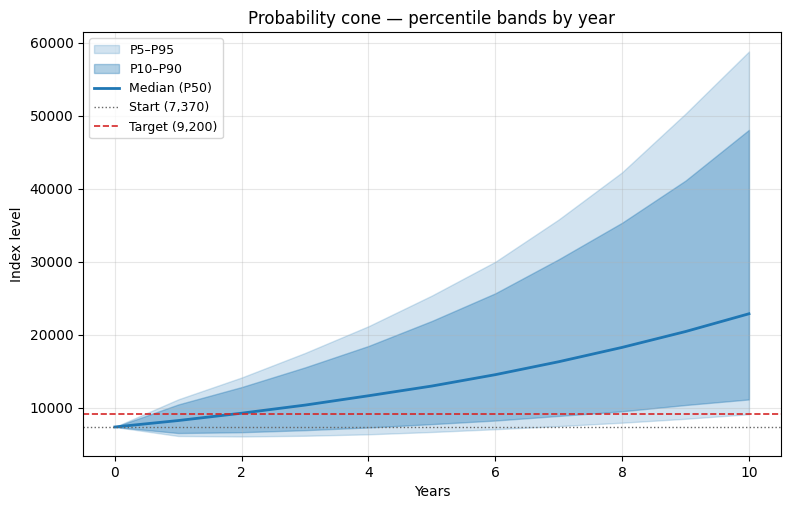

P(level >= 9,200 by year 10) = 0.9486  (94.86%)


In [4]:
bands = percentile_bands(result)
fig, ax = plt.subplots(figsize=(9, 5.5))
TARGET = round(cal.spot * 1.25, -2)
plot_cone(bands, params.spot, ax=ax, target=TARGET)
plt.show()

prob = target_probability(result, TARGET, HORIZON_YEARS)
print(f"P(level >= {TARGET:,.0f} by year {HORIZON_YEARS}) = {prob:.4f}  ({prob*100:.2f}%)")

## 4. Convergence diagnostic

The probability estimate is recomputed as the running mean over an increasing number of paths. A flat tail justifies the chosen iteration count rather than assuming it is sufficient.

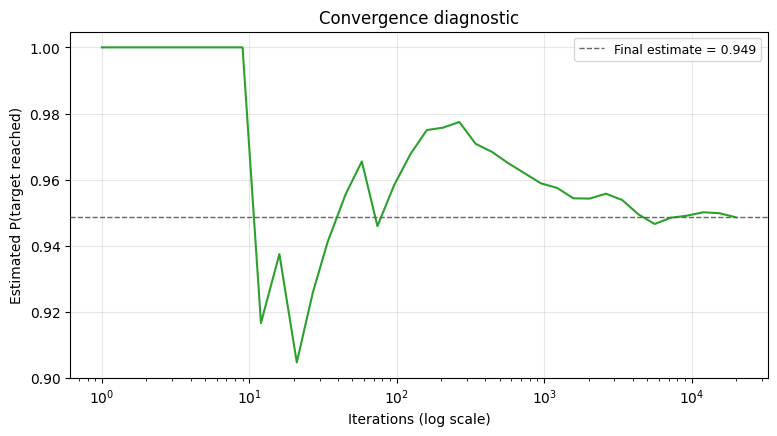

In [5]:
curve = convergence_curve(result, TARGET, HORIZON_YEARS)
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_convergence(curve, ax=ax)
plt.show()

## Optional: propagating parameter uncertainty

Point estimates understate uncertainty. Treating $\mu$ as a Triangular(low, most-likely, high) distribution propagates parameter uncertainty into the output, widening the terminal spread.

In [6]:
drift = DriftSpec.triangular(cal.mu - 0.04, cal.mu, cal.mu + 0.04)
params_u = Parameters.from_calibration(cal, horizon_years=HORIZON_YEARS, drift=drift,
                                       n_iterations=ITERATIONS, seed=SEED)
result_u = simulate(params_u)
print(f"Terminal std — fixed drift:      {result.terminal.std():,.0f}")
print(f"Terminal std — Triangular drift: {result_u.terminal.std():,.0f}")

Terminal std — fixed drift:      16,683
Terminal std — Triangular drift: 17,822


## Limitations

This is **conditional illustration, not prediction**. Every output is contingent on the calibrated $\mu$ and $\sigma$ continuing to hold. Constant-parameter GBM does not capture regime shifts, fat tails, or volatility clustering, and calibration is backward-looking. Monte Carlo propagates input assumptions into an output distribution — garbage in, garbage out. Educational use only; not financial advice. See `readme.txt`.